### 考虑到子环境自动更新，只基于固定steps构建算法更新逻辑

### 串行

Steps:   0%|          | 800/160000 [01:49<6:03:10,  7.31it/s, steps=159800, return=-268.375]


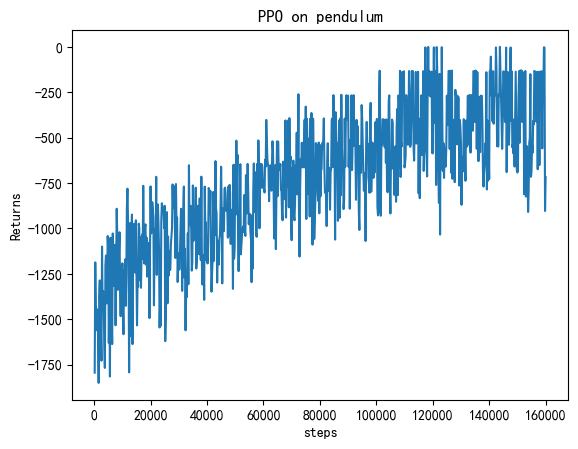

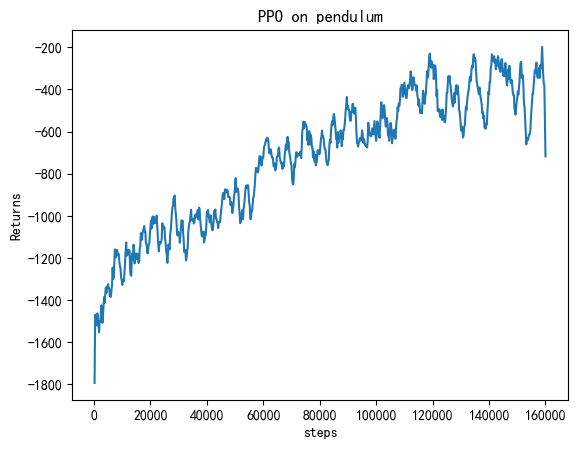

In [2]:
import sys
import os
import numpy as np
import torch as th
from math import *
import gymnasium as gymn
# from gym import spaces
import copy
import matplotlib.pyplot as plt
# import json
# import glob
import time

# 设置字体以支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取project目录
def get_current_file_dir():
    # 判断是否在 Jupyter Notebook 环境
    try:
        shell = get_ipython().__class__.__name__  # ← 误报，不用管
        if shell == 'ZMQInteractiveShell':  # Jupyter Notebook 或 JupyterLab
            # 推荐用 os.getcwd()，指向启动 Jupyter 的目录
            return os.getcwd()
        else:  # 其他 shell
            return os.path.dirname(os.path.abspath(__file__))
    except NameError:
        # 普通 Python 脚本
        return os.path.dirname(os.path.abspath(__file__))
current_dir = get_current_file_dir()
sys.path.append(os.path.dirname(current_dir))

from Algorithms.SquashedPPOcontinues_dual_a_out import *

######## 调用环境


env = gymn.make("Pendulum-v1")
from tqdm import tqdm
obs_space = env.observation_space
action_space = env.action_space

# dof = 3
# 超参数
actor_lr = 1e-4 # 1e-4 1e-6  # 2e-5 警告，学习率过大会出现"nan"
critic_lr = actor_lr * 50  # *10 为什么critic学习率大于一都不会梯度爆炸？ 为什么设置成1e-5 也会爆炸？ chatgpt说要actor的2~10倍
max_steps = 800*200  # 2000 400
hidden_dim = [128]  # 128
gamma = 0.9
lmbda = 0.9
epochs = 10  # 10
eps = 0.2
k_entropy=0
transition_dict_capacity = 200
num_envs = 1 # 子环境数目

state_dim = obs_space.shape[0]
action_dim = action_space.shape[0]
action_bound = np.array([action_space.low, action_space.high]).T  # 动作幅度限制


device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device, k_entropy)

out_range_count = 0
steps_list = []
return_list = []

start_time = time.time()
steps_since_update = 0
transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}

try:
    # 强化学习训练
    rl_steps = 0
    i_episode = 0
    with tqdm(total=int(max_steps), desc='Steps') as pbar:  # 进度条
        while rl_steps < max_steps:
            i_episode += 1
            episode_return = 0         
            state, _ = env.reset()
            done = False
            while not done:  # 每个训练回合
                # 1.执行动作得到环境反馈
                action, u = agent.take_action(state, action_bounds=action_bound, explore=True)
                rl_steps += 1
                total_action = action

                next_state, reward, terminated, truncated, _ = env.step(total_action)
                done = terminated or truncated

                transition_dict['states'].append(state)
                transition_dict['actions'].append(u)
                transition_dict['next_states'].append(next_state)
                transition_dict['rewards'].append((reward + 8.0) / 8.0)
                transition_dict['dones'].append(done)
                transition_dict['action_bounds'].append(action_bound)
                state = next_state
                episode_return += reward
                steps_since_update += 1

                if steps_since_update >= transition_dict_capacity:
                    steps_since_update = 0
                    agent.update(transition_dict, shuffled=1)
                    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}

            steps_list.append(rl_steps)
            return_list.append(episode_return)
            
            # tqdm 训练进度显示
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({'steps': '%d' % (rl_steps),
                                'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

except KeyboardInterrupt:
    print("\n检测到 KeyboardInterrupt，正在关闭 logger ...")
finally:
    def moving_average(a, window_size):
        cumulative_sum = np.cumsum(np.insert(a, 0, 0))
        middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
        r = np.arange(1, window_size - 1, 2)
        begin = np.cumsum(a[:window_size - 1])[::2] / r
        end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
        return np.concatenate((begin, middle, end))
    # 记录训练结束时间
    end_time = time.time()
    training_duration = end_time - start_time

    plt.figure()
    plt.plot(steps_list, return_list)
    plt.xlabel('steps')
    plt.ylabel('Returns')
    plt.title('PPO on pendulum')

    mv_return = moving_average(return_list, 9)
    plt.figure()
    plt.plot(steps_list, mv_return)
    plt.xlabel('steps')
    plt.ylabel('Returns')
    plt.title('PPO on pendulum')

    plt.show()

### Sync

Steps: 100%|██████████| 160000/160000 [01:55<00:00, 1380.43it/s, steps=160000, return=-410.306]


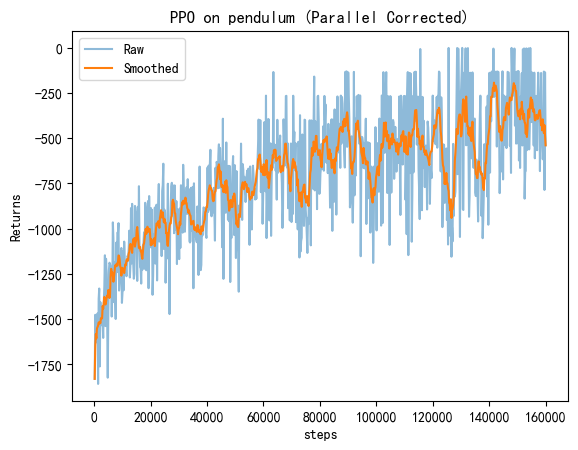

In [5]:
import sys
import os
import numpy as np
import torch as th
from math import *
import gymnasium as gymn
import copy
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
# partial
from functools import partial

# 设置字体以支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取project目录
def get_current_file_dir():
    try:
        shell = get_ipython().__class__.__name__
        if shell == 'ZMQInteractiveShell':
            return os.getcwd()
        else:
            return os.path.dirname(os.path.abspath(__file__))
    except NameError:
        return os.path.dirname(os.path.abspath(__file__))
current_dir = get_current_file_dir()
sys.path.append(os.path.dirname(current_dir))

from Algorithms.SquashedPPOcontinues_dual_a_out_new import *

# ====== 使用矢量化环境 ======
# 行为：当子环境返回 terminated 或 truncated 时，AutoResetWrapper 会自动 reset
# 返回的 obs 是 reset 后的，但 terminated/truncated 依然为 True 以便算法识别
class AutoResetWrapper(gymn.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        if done:
            info = info if isinstance(info, dict) else {}
            info['final_observation'] = obs
            new_obs, new_info = self.env.reset()
            if isinstance(new_info, dict):
                info.update({'reset_info': new_info})
            return new_obs, reward, terminated, truncated, info
        else:
            return obs, reward, terminated, truncated, info

# 可调用类
class EnvFactory:
    def __init__(self, seed):
        self.seed = seed
    def __call__(self):
        env = AutoResetWrapper(gymn.make("Pendulum-v1"))
        env.reset(seed=self.seed)
        return env
    
# 超参数
actor_lr = 1e-4
critic_lr = actor_lr * 50
max_steps = 800*200
hidden_dim = [128]
gamma = 0.9
lmbda = 0.9
epochs = 10
eps = 0.2
k_entropy = 0
transition_dict_capacity = 200
num_envs = 1 # 子环境数目，建议设置为 1 进行对比测试，之后再增加

# 创建环境
env_fns = [EnvFactory(i) for i in range(num_envs)]
env = gymn.vector.SyncVectorEnv(env_fns)

obs_space = env.single_observation_space
action_space = env.single_action_space

state_dim = obs_space.shape[0]
action_dim = action_space.shape[0]
action_bound = np.array([action_space.low, action_space.high]).T

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                      lmbda, epochs, eps, gamma, device, k_entropy)

# 统计变量
steps_list = []
return_list = []

start_time = time.time()
steps_since_update = 0

# 为每个子环境维护独立缓冲
per_env_buffers = [
    {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
    for _ in range(num_envs)
]

# 【修改2】维护每个子环境当前的 episode return
# 这样任何一个子环境 done 了，我们都记录下来，这与串行代码逻辑一致
current_episode_returns = np.zeros(num_envs)

try:
    rl_steps = 0
    with tqdm(total=int(max_steps), desc='Steps') as pbar:
        states, _ = env.reset()
        
        while rl_steps < max_steps:
            rl_steps += 1
            
            # 1.执行动作
            actions = []
            us = []
            for state in states:
                action, u = agent.take_action(state, action_bounds=action_bound, explore=True)
                actions.append(action)
                us.append(u)
            actions = np.array(actions)

            next_states, rewards, terminateds, truncateds, infos = env.step(actions)
            dones = np.logical_or(terminateds, truncateds)

            for i in range(num_envs):
                # 记录 reward
                current_episode_returns[i] += rewards[i]

                # 存入 per-env buffer
                per_env_buffers[i]['states'].append(states[i])
                per_env_buffers[i]['actions'].append(us[i])
                per_env_buffers[i]['next_states'].append(next_states[i])
                per_env_buffers[i]['rewards'].append((rewards[i] + 8.0) / 8.0)
                per_env_buffers[i]['dones'].append(dones[i])
                per_env_buffers[i]['action_bounds'].append(action_bound)

                # 【修改3】事件触发式记录：如果当前子环境结束，记录该回合回报
                if dones[i]:
                    return_list.append(current_episode_returns[i])
                    steps_list.append(rl_steps) # 记录当前的全局步数
                    current_episode_returns[i] = 0.0
                    
            states = next_states
            steps_since_update += 1
            
            # 2.更新策略
            if steps_since_update >= transition_dict_capacity:
                steps_since_update = 0
                
                # 【修改4】分环境计算 GAE，然后合并
                # 这样可以正确处理子环境的截断（Bootstrap），并且不会混淆 Env1 和 Env2 的数据
                transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 
                                   'dones': [], 'action_bounds': [], 'advantages': [], 'td_targets': []}
                
                for i in range(num_envs):
                    ebuf = per_env_buffers[i]
                    if len(ebuf['states']) == 0: continue
                    
                    # 【重要修复】绝对不要强制置 dones[-1] = True
                    # PPO 算法内部会利用 ebuf['next_states'][-1] 和 ebuf['dones'][-1]
                    # 来正确处理截断情况（如果 done=False，则 V(next) 作为 target）。
                    
                    # 调用新加的 API，在合并前计算该子环境的 GAE
                    ebuf = agent.compute_gae_for_buffer(ebuf)
                    
                    # 合并数据
                    transition_dict['states'].extend(ebuf['states'])
                    transition_dict['actions'].extend(ebuf['actions'])
                    transition_dict['next_states'].extend(ebuf['next_states'])
                    transition_dict['rewards'].extend(ebuf['rewards'])
                    transition_dict['dones'].extend(ebuf['dones'])
                    transition_dict['action_bounds'].extend(ebuf['action_bounds'])
                    transition_dict['advantages'].extend(ebuf['advantages'])
                    transition_dict['td_targets'].extend(ebuf['td_targets'])

                # 【修改5】统一 API，开启 shuffled=1 以打破数据相关性
                agent.update(transition_dict, shuffled=1)
                
                # 清空 buffer
                per_env_buffers = [
                    {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
                    for _ in range(num_envs)
                ]

            # tqdm 更新
            if rl_steps % 200 == 0:
                pbar.update(200)
                if len(return_list) > 0:
                    recent_mean = np.mean(return_list[-10:])
                    pbar.set_postfix({'steps': '%d' % rl_steps, 'return': f'{recent_mean:.3f}'})

except KeyboardInterrupt:
    print("\n检测到 KeyboardInterrupt")
finally:
    def moving_average(a, window_size):
        if len(a) < window_size: return np.array(a)
        cumulative_sum = np.cumsum(np.insert(a, 0, 0))
        middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
        r = np.arange(1, window_size - 1, 2)
        begin = np.cumsum(a[:window_size - 1])[::2] / r
        end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
        return np.concatenate((begin, middle, end))

    end_time = time.time()
    
    # 绘图（此时 steps_list 和 return_list 的定义与串行代码完全一致）
    plt.figure()
    plt.plot(steps_list, return_list, alpha=0.5, label='Raw')
    plt.xlabel('steps')
    plt.ylabel('Returns')
    plt.title('PPO on pendulum (Parallel Corrected)')
    
    if len(return_list) > 10:
        mv_return = moving_average(return_list, 9)
        plt.plot(steps_list, mv_return, label='Smoothed')
    
    plt.legend()
    plt.show()

### Async

Steps:   1%|▏         | 2380/160000 [04:46<5:16:25,  8.30it/s, steps=159593, return=-450.691]


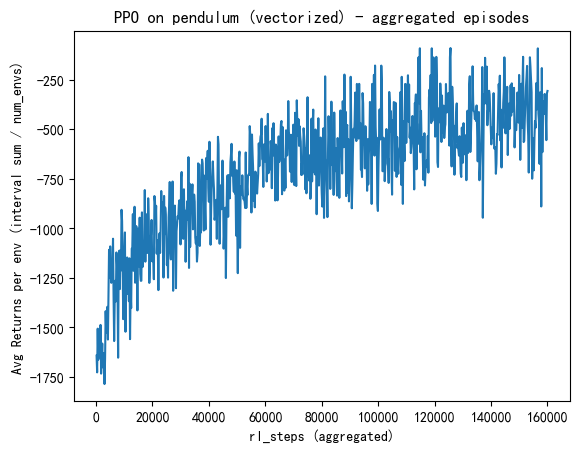

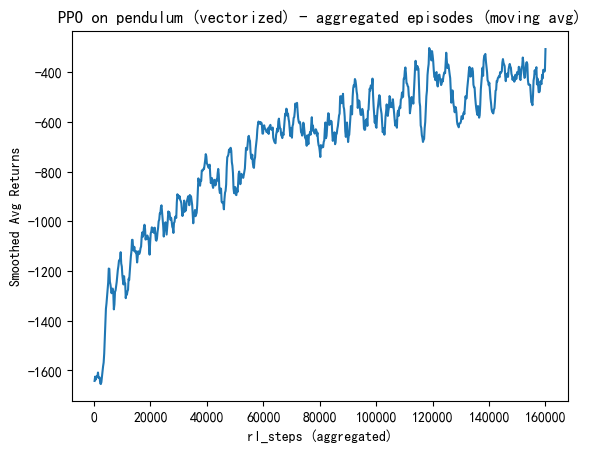

In [6]:
import sys
import os
import numpy as np
import torch as th
from math import *
import gymnasium as gymn
# from gymnasium.wrappers import AutoResetEnv
# from gym import spaces
import copy
import matplotlib.pyplot as plt
# import json
# import glob
import time

# 设置字体以支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 获取project目录
def get_current_file_dir():
    # 判断是否在 Jupyter Notebook 环境
    try:
        shell = get_ipython().__class__.__name__  # ← 误报，不用管
        if shell == 'ZMQInteractiveShell':  # Jupyter Notebook 或 JupyterLab
            # 推荐用 os.getcwd()，指向启动 Jupyter 的目录
            return os.getcwd()
        else:  # 其他 shell
            return os.path.dirname(os.path.abspath(__file__))
    except NameError:
        # 普通 Python 脚本
        return os.path.dirname(os.path.abspath(__file__))
current_dir = get_current_file_dir()
sys.path.append(os.path.dirname(current_dir))

from Algorithms.SquashedPPOcontinues_dual_a_out import *

######## 调用环境

# ====== 使用矢量化环境 ======

# 由于 gymnasium 1.0.0 没有 AutoResetEnv，这里实现一个小的兼容包装器。
# 行为：当子环境返回 terminated 或 truncated 时，先保存 final observation，
# 然后立即对该子环境调用 reset() 并把 reset 后的 observation返回给外层，但保留 terminated/truncated=True
# 这样外层可以检测到该子环境完成 episode（通过 terminated/truncated），同时下一步状态就是自动重置后的初始观测。
class AutoResetWrapper(gymn.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        if done:
            # 保存 final obs 到 info（可选）
            info = info if isinstance(info, dict) else {}
            info['final_observation'] = obs
            # 自动重置该子环境并返回 reset 后的 obs（保持 terminated/truncated=True）
            new_obs, new_info = self.env.reset()
            # 合并 info（保留 reset 返回的 info 字典）
            if isinstance(new_info, dict):
                info.update({'reset_info': new_info})
            return new_obs, reward, terminated, truncated, info
        else:
            return obs, reward, terminated, truncated, info

# --------------- 在模块顶层定义一个可 picklable 的 env 工厂 ---------------
def make_env_fn(seed_offset=0):
    """返回一个零参数的可调用 thunk，供 AsyncVectorEnv 使用（顶层可 picklable）"""
    def _thunk():
        env = AutoResetWrapper(gymn.make("Pendulum-v1"))
        # 注意：不要在这里调用 env.reset(seed=...)，改为在主流程的 transition_dict_capacity 定义后统一 reset
        return env
    return _thunk

# dof = 3
# 超参数
actor_lr = 1e-4 # 1e-4 1e-6  # 2e-5 警告，学习率过大会出现"nan"
critic_lr = actor_lr * 50  # *10 为什么critic学习率大于一都不会梯度爆炸？ 为什么设置成1e-5 也会爆炸？ chatgpt说要actor的2~10倍
max_steps = 800*200  # 2000 400
hidden_dim = [128]  # 128
gamma = 0.9
lmbda = 0.9
epochs = 10  # 10
eps = 0.2
k_entropy=0
transition_dict_capacity = 200
num_envs = 3 # 子环境数目

if __name__ == '__main__':
    # 使用 make_env_fn 创建适用于 AsyncVectorEnv 的环境构造函数列表
    env_fns = [make_env_fn(i) for i in range(num_envs)]

    env = gymn.vector.AsyncVectorEnv(env_fns)
    from tqdm import tqdm
    obs_space = env.single_observation_space
    action_space = env.single_action_space

    state_dim = obs_space.shape[0]
    action_dim = action_space.shape[0]
    action_bound = np.array([action_space.low, action_space.high]).T  # 动作幅度限制

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    agent = PPOContinuous(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                          lmbda, epochs, eps, gamma, device, k_entropy)

    out_range_count = 0
    steps_list = []
    return_list = []
    steps_count = 0

    start_time = time.time()
    steps_since_update = 0
    # 全局 transition_dict 保持用于传入 agent.update
    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
    # 新增：为每个子环境维护独立缓冲，保证按 env 首尾相连拼接
    per_env_buffers = [
        {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
        for _ in range(num_envs)
    ]

    # 新增：用于“齐步”计数和按 num_envs 聚合的平均 episode 统计
    cumulative_done_count = 0               # 累计的 done 计数（跨所有 env）
    interval_total_reward = 0.0             # 从上次聚合事件到当前的总奖励（所有 env 的和）
    avg_return_list = []                    # 存放按聚合事件计算的平均返回（每个聚合区间总奖励 / num_envs）
    rl_steps_list = []                      # 存放每次聚合事件对应的 rl_steps（x 轴）

    try:
        # 强化学习训练
        rl_steps = 0
        with tqdm(total=int(max_steps), desc='Steps') as pbar:  # 进度条
            episode_idx = 0
            last_reported = 0  # 上次向 tqdm 报告的已完成 episode 总数（按 10 的倍数报告）
            # 按子环境独立进行 episode 收集，直到收集到 num_episodes 个 episode
            states, _ = env.reset()
            episode_returns = np.zeros(num_envs)
            while rl_steps < max_steps:
                rl_steps += 1
                # 1.执行动作得到环境反馈（对每个子环境）
                actions = []
                us = []
                for state in states:
                    action, u = agent.take_action(state, action_bounds=action_bound, explore=True)
                    actions.append(action)
                    us.append(u)
                actions = np.array(actions)

                next_states, rewards, terminateds, truncateds, infos = env.step(actions)
                dones = np.logical_or(terminateds, truncateds)

                # 本次齐步的总奖励（raw，numpy 数组），计入 interval_total_reward
                interval_total_reward += float(np.sum(rewards))

                for i in range(num_envs):
                    # 先写入 per-env 缓冲，保持每个 env 的序列连续
                    per_env_buffers[i]['states'].append(states[i])
                    per_env_buffers[i]['actions'].append(us[i])
                    per_env_buffers[i]['next_states'].append(next_states[i])
                    per_env_buffers[i]['rewards'].append((rewards[i] + 8.0) / 8.0)
                    per_env_buffers[i]['dones'].append(dones[i])
                    per_env_buffers[i]['action_bounds'].append(action_bound)
                    episode_returns[i] += rewards[i]
                    # 不在这里累加 steps_count（每个齐步只计 1）

                    # 如果子环境完成一个 episode，记录并重置该子环境的累计返回（AutoResetWrapper 已自动重置状态）
                    if dones[i]:
                        return_list.append(episode_returns[i])
                        episode_idx += 1
                        episode_returns[i] = 0.0
                        # 增加跨 env 的累计 done 计数；当累计到 num_envs 时视为一个聚合 episode 事件
                        cumulative_done_count += 1

                # 齐步计数：把 steps_count 与 rl_steps 对齐（每次 vector step 只算 1）
                steps_count = rl_steps

                # 当累计 done 数达到 num_envs 时，视为一个“平均 episode”事件：记录 interval_total_reward/num_envs
                # 支持在同一步可能触发多个聚合事件（极少见）
                while cumulative_done_count >= num_envs:
                    avg = interval_total_reward / float(num_envs)
                    avg_return_list.append(avg)
                    rl_steps_list.append(rl_steps)
                    cumulative_done_count -= num_envs
                    # 重置 interval_total_reward，为下一个聚合区间开始累计
                    interval_total_reward = 0.0

                states = next_states
                steps_since_update += 1
                
                if steps_since_update >= transition_dict_capacity:
                    steps_since_update = 0
                    # 按 env 索引顺序把每个 env 的缓冲首尾相连拼到 transition_dict，再 update
                    transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
                    for ebuf in per_env_buffers:
                        transition_dict['states'].extend(ebuf['states'])
                        transition_dict['actions'].extend(ebuf['actions'])
                        transition_dict['next_states'].extend(ebuf['next_states'])
                        transition_dict['rewards'].extend(ebuf['rewards'])
                        transition_dict['dones'].extend(ebuf['dones'])
                        transition_dict['action_bounds'].extend(ebuf['action_bounds'])
                    agent.update(transition_dict)
                    # 清空 per-env 缓冲以便下一轮收集
                    per_env_buffers = [
                        {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': [], 'action_bounds': []}
                        for _ in range(num_envs)
                    ]

                # tqdm 训练进度显示（仅当累计完成的 episode 达到 10 的倍数时更新进度条）
                completed_groups = episode_idx // 10
                last_reported_groups = last_reported // 10
                if completed_groups > last_reported_groups:
                    increments = (completed_groups - last_reported_groups) * 10
                    pbar.update(increments)
                    # 显示最近 10 个 episode 的平均返回（如果不足 10 个则显示已有的平均）
                    if len(return_list) >= 10:
                        recent_mean = np.mean(return_list[-10:])
                    else:
                        recent_mean = np.mean(return_list) if return_list else 0.0
                    # 保证为有限数值并格式化，强制刷新 tqdm 输出
                    if not np.isfinite(recent_mean):
                        recent_mean = 0.0
                    pbar.set_postfix({'steps': '%d' % (steps_count),
                                      'return': f'{recent_mean:.3f}'}, refresh=True)
                    last_reported = completed_groups * 10

    except KeyboardInterrupt:
        print("\n检测到 KeyboardInterrupt")
    finally:
        def moving_average(a, window_size):
            cumulative_sum = np.cumsum(np.insert(a, 0, 0))
            middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
            r = np.arange(1, window_size - 1, 2)
            begin = np.cumsum(a[:window_size - 1])[::2] / r
            end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
            return np.concatenate((begin, middle, end))
        # 记录训练结束时间
        end_time = time.time()
        training_duration = end_time - start_time

        episodes_list = rl_steps_list
        # 使用聚合事件的 rl_steps_list 作为 x 轴，avg_return_list 作为 y 轴绘图
        plt.figure()
        plt.plot(episodes_list, avg_return_list)
        plt.xlabel('rl_steps (aggregated)')
        plt.ylabel('Avg Returns per env (interval sum / num_envs)')
        plt.title('PPO on pendulum (vectorized) - aggregated episodes')

        if len(avg_return_list) > 0:
            mv_return = moving_average(avg_return_list, 9)
            plt.figure()
            plt.plot(episodes_list, mv_return)
            plt.xlabel('rl_steps (aggregated)')
            plt.ylabel('Smoothed Avg Returns')
            plt.title('PPO on pendulum (vectorized) - aggregated episodes (moving avg)')
        plt.show()